# Sensor placement report

Reads what the `sensor_placement` pipeline produced for the **last world built in this
project** (or for any world clone: point `PROJECT` at its `clone/` directory), and keeps the
POC's reporting: the cache logic, every measured quantity, the verification and sanity
checks, the three interactive browsers, and §7 — do the selected sets make sense?

Two stacks can sit behind one placement. The **selection** stack (reference coupling) decided
which gauges fill the slots; the **label** stack (the world's realised coupling) supplied the
`w_<District>` mixture written for each of them. For a world at the reference coupling they
are the same stack.

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

HERE = Path.cwd()
# PROJECT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
PROJECT = Path("../data/09_experiments/worlds/c5c8904c3d8c/clone")  
# PROJECT = Path("data/09_experiments/worlds/<sim_hash>/clone")   # a cached world
bootstrap_project(PROJECT)
session = KedroSession.create(project_path=PROJECT)
context = session.load_context()
catalog, params = context.catalog, context.params

from fedwater.placement import browsers as B
from fedwater.placement import classification as cl
from fedwater.placement import figures as F
from fedwater.placement import mixture_probe as mp
from fedwater.placement import signal_probe as sp
from fedwater.placement import store
from fedwater.placement.topology import topology

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 250)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8})

SP = params["sensor_placement"]
POINTER = catalog.load("placement_stacks")
if POINTER["source"] != "dynamic":
    raise SystemExit("this world used sensor_placement.source = manual: no probe "
                     "stacks to report on")
PLACEMENT = catalog.load("sensor_placement")
NETWORK = POINTER["network"]
S = store.load_stack(POINTER["selection"]["path"], with_probes=True)
L = S if POINTER["same_stack"] else store.load_stack(POINTER["label"]["path"])
TOPO = topology(PROJECT / "data" / "01_raw" / NETWORK / "network.inp")
print(f"{NETWORK} / {POINTER['districting']} (partition {POINTER['partition_id']})")
print(f"selection stack {S.stack_hash} | label stack {L.stack_hash}"
      f"{'  (same)' if POINTER['same_stack'] else ''}")

[09/16/26 16:30:22] INFO     Using                                                                  ]8;id=615484;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=127684;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[09/16/26 16:30:25] INFO     No typed parameter requirements found, returning original   ]8;id=608268;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=53519;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=404162;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=836032;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Loading data from placement_stacks (YAMLDataset)...               ]8;id=526857;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=116209;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from sensor_placement (CSVDataset)...                ]8;id=789620;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=318550;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

ky72 / girvan_newman (partition 6f359aad)
selection stack 9daaa69d72b3 | label stack 9daaa69d72b3  (same)


## 1. Cache logic

A stack is identified by `canonical_hash` of its spec: network, partition content, `.inp`
content, initial consumption map, the resolved operating point (anchor, beta, land use,
buildings), the probe horizon, coupling, seed, transitions and the analysis thresholds. It
does **not** include the world's drift target or seed node, nor the selection settings — so
every world that shares an initial map at one operating point reuses one stack, and changing
`slots` re-selects without re-solving.

A stack is served only when its manifest says `ok` and its hash matches; a `failed` manifest
is rebuilt on the next request. `src_drift` flags a stack built by different code: reported,
not invalidated (the engine's policy for worlds).

In [2]:
display(pd.DataFrame([
    {"role": role, **{k: POINTER[role][k] for k in ("stack_hash", "seed", "src_drift")},
     "coupling": POINTER[role]["coupling"]["variant"],
     "closed": ";".join(POINTER[role]["coupling"].get("closed", []))}
    for role in ("selection", "label")]))
print("world coupling:", POINTER.get("world_coupling"), "| plan:", POINTER["plan"])

import json
rows = []
root = Path(POINTER["selection"]["path"]).parent
for d in sorted(p for p in root.iterdir() if p.is_dir()):
    m = json.loads((d / "manifest.json").read_text()) if (d / "manifest.json").exists() else {}
    spec = m.get("spec", {})
    rows.append({"stack": d.name, "status": m.get("status"),
                 "init_map": "_".join(i[0][0].upper() + i[1][0].upper()
                                      for i in spec.get("init_map", [])),
                 "coupling": (spec.get("coupling") or {}).get("variant"),
                 "anchor": (spec.get("hydraulics") or {}).get("anchor_scale"),
                 "beta": spec.get("beta"), "months": (spec.get("plan") or {}).get("n_months"),
                 "minutes": round(float(m.get("seconds", 0)) / 60, 1),
                 "size_MB": round(sum(f.stat().st_size for f in d.rglob("*")
                                      if f.is_file()) / 1e6),
                 "src_drift": m.get("src_hash") != store.src_hash(),
                 "in_use": d.name in (S.stack_hash, L.stack_hash),
                 "error": (m.get("error") or "")[:80]})
display(pd.DataFrame(rows))

,role,stack_hash,seed,src_drift,coupling,closed
0,selection,9daaa69d72b3,42,False,baseline,
1,label,9daaa69d72b3,42,False,baseline,


world coupling: {'close_fraction': 0.0, 'variant': 'baseline'} | plan: {'convert_months': 32, 'days_per_month': 14, 'drift_ramp_days': 7, 'growth_chance': 1.0, 'largest_district': 237, 'max_eccentricity': 32, 'max_neighbors_per_month': 8, 'modes': {'diffusion': 'planned', 'horizon': 'world', 'seasonality': 'world'}, 'n_months': 55, 'need_n_months': 54, 'season_aligned': False, 'seasonality_scale': 0.0, 'warmup_months': 12}


,stack,status,init_map,coupling,anchor,beta,months,minutes,size_MB,src_drift,in_use,error
0,05d0d7fb8c7d,ok,LR_LR_LR_LR,baseline,0.5,0.50,55,5.2,927,False,False,
1,9daaa69d72b3,ok,LR_LR_LR_LR,baseline,0.5,0.35,55,4.8,926,False,True,
2,de3a6572644c,ok,LR_LR_LR_LR,baseline,0.5,0.50,50,5.1,843,True,False,


## 2. The probe design

One probe world per district, each converting that district's land use through
`sensor_placement.probe.transitions` from its **initial** regime. The front width is derived
from the largest district and the horizon from the seeds' eccentricity, so the largest
district still has a settled tail. `coverage` is the share of a district its seed reaches
without leaving it; below 1.0 the mixture measures a partial conversion.

In [3]:
display(S.seeds)
display(S.horizon)

,district,seed_node,n_nodes,eccentricity,coverage,stack_hash,to_land_use
0,District_A,J-94,237,32,1.0,9daaa69d72b3,industrial
1,District_B,J-121,105,13,1.0,9daaa69d72b3,industrial
2,District_C,J-207,99,26,1.0,9daaa69d72b3,industrial
3,District_D,J-15,40,8,1.0,9daaa69d72b3,industrial


,drift_district,n_months,last_switch,settle_month,settled_from,settled_months,ok,need_n_months
0,District_A,55,51,45,46,9,True,49
1,District_B,55,29,26,27,28,True,30
2,District_C,55,38,32,33,22,True,36
3,District_D,55,20,19,20,35,True,23


### 2a. Did the drift land where it was aimed?

`in_target` must be 1.00 everywhere and the seed must sit in its own district. Seeds follow
the project rule: the profile's `drift_seed_nodes` on the manual partition, the
largest-base-demand junction on a generated one.

In [4]:
rows = []
for d, P in S.probes.items():
    sch = P.schedule
    tgt = set(P.districts[d])
    seeded = set(sch["node"].astype(str))
    first = sch.loc[sch["drift_month"] == sch["drift_month"].min(), "node"].astype(str)
    rows.append({"drift_district": d, "n_scheduled": len(sch),
                 "in_target": round(len(seeded & tgt) / max(len(seeded), 1), 3),
                 "coverage": round(len(seeded & tgt) / len(tgt), 3),
                 "seed_node": list(first)[0], "seed_in_target": list(first)[0] in tgt,
                 "to_land_use": sch["to_land_use"].iloc[0],
                 "first_month": int(sch["drift_month"].min()),
                 "last_month": int(sch["drift_month"].max())})
SEEDCHK = pd.DataFrame(rows)
display(SEEDCHK)
assert (SEEDCHK["in_target"] == 1.0).all(), "drift scheduled outside its target district"
assert SEEDCHK["seed_in_target"].all(), "seed node is not in the district it seeds"
print("seed resolution ok")

,drift_district,n_scheduled,in_target,coverage,seed_node,seed_in_target,to_land_use,first_month,last_month
0,District_A,237,1.0,1.0,J-94,True,industrial,12,51
1,District_B,105,1.0,1.0,J-121,True,industrial,12,29
2,District_C,99,1.0,1.0,J-207,True,industrial,12,38
3,District_D,40,1.0,1.0,J-15,True,industrial,12,20


seed resolution ok


### 2b. Settling

`final` cannot start at `last_switch + ramp`: the profile is still moving there. The threshold
is self-calibrating — the reproducibility ceiling is measured from the reference months, and
"settled" means within a slack of it. A stack whose settled window is too short is not
built: it raises and asks for a longer probe horizon.

,district,drifted,settle_month,ceiling,threshold,r_min,r_at_first_final,drift_district
0,District_A,True,45,0.9999,0.9899,0.2725,0.9999,District_A
5,District_B,True,26,0.9998,0.9898,0.2749,0.9998,District_B
10,District_C,True,32,0.9999,0.9899,0.2723,0.9994,District_C
15,District_D,True,19,0.9997,0.9897,0.2680,0.9996,District_D


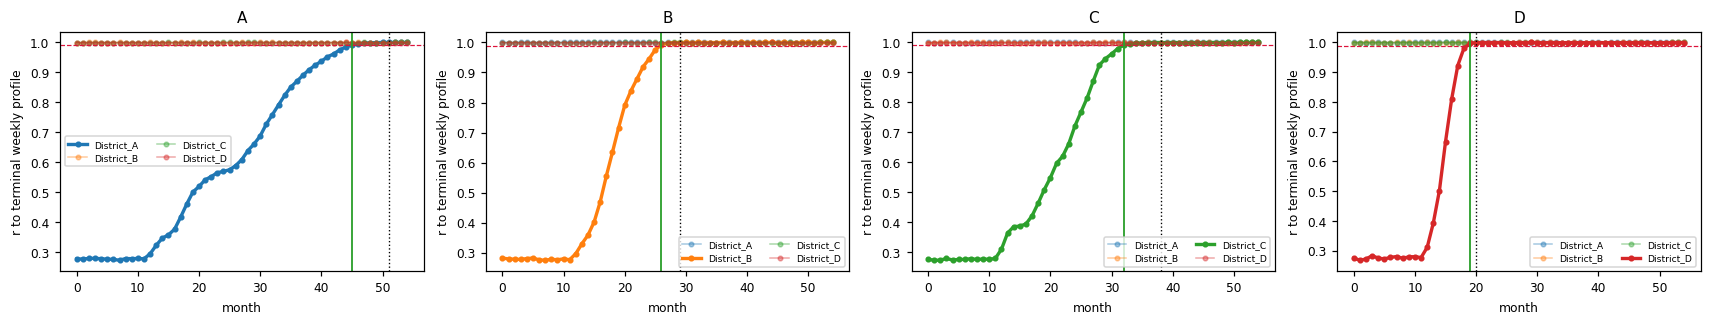

In [5]:
display(S.settle[S.settle["drifted"]])
fig, axes = plt.subplots(1, len(S.probes), figsize=(3.9 * len(S.probes), 3.0), squeeze=False)
F.settle_panel(axes[0], S.probes, ref_months=SP["probe"]["settle"]["ref_months"],
               slack=SP["probe"]["settle"]["slack"])
plt.tight_layout(); plt.show()

## 3. The quantities

**Excitation.** Each probe converts one district. On the z-scored weekly profile, `Δz_d(k)` is
that district's change of *temporal signature* — a pure level change scores zero, which is the
point: level is what per-client MinMax scaling destroys, shape is what survives it.

**Elasticity `E[s,k]`.** A gauge's own `Δz_s` projected on the unit direction of `Δz_d(k)`,
soft-thresholded against the projection noise `ν` measured on the same direction, divided by
the excitation size: how much of district k's signature reached this gauge, per unit of k's
change. Measured in `shape` (z-scored) and `native` space.

**Mixture.** A gauge's positive responses normalised across k. `purity` is its own district's
share; `w_second` the largest foreign share. The tiers (`core` / `transition` / `foreign` /
`unusable`) are regions of that axis; the slots read `pure` = `core`, `mixed` =
`w_second ≥ mixed_min_foreign` with `n_mass ≥ min_n_mass` and a stable purity.

**Dependence `D[j,k]` and `R = D/diag(D)`.** `|E|` averaged over *every* gauge homed in j —
not the best few, because selecting the purest gauges and then measuring purity drives the
off-diagonal to zero by construction. `R[j,k]`: j's meters respond R as strongly to k's drift
as to j's own. Asymmetric on purpose; `R > 1` is meaningful.

**Response matrices** are the transpose restricted to a tier; **leak** is the same question
asked through the resemblance battery (top-3 resembling gauges per district).

**The limit of the claim.** Each district's demand is generated independently, so nothing here
says j's *demand* depends on k's. It says j's *observations* are contaminated by k's demand —
measured from real conversions at the world's operating point. Influence, not causality.

### 3a. Is the mixture informative, or is the threshold doing the work?

In [6]:
display(S.diagnostics)
display(S.tier_sensitivity)
display(S.purity_histogram)
display(S.stability.describe().round(3))

,kind,n,unusable_%,n_live<=1_%,n_live_mean,purity_median,snr_median,neg_mass_%
0,flow,604,4.636,31.623,2.992,1.0,14.669,63.576
1,pressure,463,97.840,0.000,4.000,1.0,9.498,100.000


,null_factor,core_purity,kind,core,transition,foreign,unusable,n_live_mean
0,1.0,0.85,flow,442,58,86,18,3.23
1,1.0,0.85,pressure,10,0,0,453,4.00
2,1.5,0.85,flow,436,58,82,28,2.99
3,1.5,0.85,pressure,10,0,0,453,4.00
4,3.0,0.85,flow,433,58,82,31,2.87
5,3.0,0.85,pressure,10,0,0,453,4.00


,kind,bin,n,share
0,flow,"[0.0, 0.15)",82,0.142
1,flow,"[0.15, 0.3)",10,0.017
2,flow,"[0.3, 0.5)",19,0.033
3,flow,"[0.5, 0.7)",15,0.026
4,flow,"[0.7, 0.85)",14,0.024
5,flow,"[0.85, 0.95)",35,0.061
6,flow,"[0.95, 1.001)",401,0.696
7,pressure,"[0.0, 0.15)",0,0.000
8,pressure,"[0.15, 0.3)",0,0.000
9,pressure,"[0.3, 0.5)",0,0.000


,purity_min,purity_max,purity_swing
count,1067.000,1067.000,1067.000
mean,0.440,0.449,0.009
std,0.481,0.482,0.092
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.000,0.000,0.000
75%,1.000,1.000,0.000
max,1.000,1.000,1.000


### 3b. Elasticity

Per kind and space: the mean `|E|` a gauge shows for its **own** district against the mean over
the **others**, and how well the two spaces agree. A shape/native disagreement is where a level
effect is doing the talking.

In [7]:
home = S.mixture.set_index("id")["home"]
rows = []
for space, E in S.elasticity.items():
    A = E.abs()
    kind = pd.Series(np.where(A.index.str.startswith("p_"), "pressure", "flow"), index=A.index)
    h = home.reindex(A.index)
    for k in ("flow", "pressure"):
        sub, hh = A[kind == k], h[kind == k]
        own = np.array([sub.loc[i, d] if d in sub.columns else np.nan
                        for i, d in zip(sub.index, hh)])
        other = (sub.sum(axis=1).to_numpy() - np.nan_to_num(own)) / max(sub.shape[1] - 1, 1)
        rows.append({"space": space, "kind": k, "n": len(sub),
                     "E_own_mean": np.nanmean(own), "E_other_mean": np.nanmean(other),
                     "own_over_other": np.nanmean(own) / max(np.nanmean(other), 1e-12)})
display(pd.DataFrame(rows).round(4))
es, en = S.elasticity["shape"], S.elasticity["native"].reindex_like(S.elasticity["shape"])
print("shape vs native elasticity, pooled correlation:",
      round(float(np.corrcoef(es.to_numpy().ravel(), en.to_numpy().ravel())[0, 1]), 3))

,space,kind,n,E_own_mean,E_other_mean,own_over_other
0,shape,flow,604,0.5703,0.0876,6.5071
1,shape,pressure,463,0.1064,0.1759,0.6047
2,native,flow,604,0.0620,0.0392,1.5809
3,native,pressure,463,0.0293,0.1147,0.2554


shape vs native elasticity, pooled correlation: 0.357


### 3c. Dependence, response, leak, and the estimator's own checks

In [8]:
for kind in ("flow", "pressure"):
    print(f"--- {kind}: R[j,k] (shape) ---")
    display(S.dependence[kind]["R"].round(3))
    display(S.dependence_summary[S.dependence_summary["kind"] == kind])
    display(S.asymmetry[kind].round(3))
    if kind in S.dependence_native:
        print(f"{kind}: R[j,k] (native)")
        display(S.dependence_native[kind]["R"].round(3))
display(S.checks)

--- flow: R[j,k] (shape) ---


,District_A,District_B,District_C,District_D
District_A,1.000,0.106,0.178,0.141
District_B,0.108,1.000,0.074,0.057
District_C,0.636,0.494,1.000,0.197
District_D,0.071,0.020,0.034,1.000


,district,in_mean,in_max,out_mean,out_max,net,strongest_source,kind
0,District_A,0.142,0.178,0.271,0.636,0.130,District_C,flow
1,District_B,0.079,0.108,0.207,0.494,0.127,District_A,flow
2,District_C,0.442,0.636,0.096,0.178,-0.347,District_A,flow
3,District_D,0.042,0.071,0.132,0.197,0.090,District_A,flow


,District_A,District_B,District_C,District_D
District_A,0.000,-0.001,-0.458,0.070
District_B,0.001,0.000,-0.420,0.037
District_C,0.458,0.420,0.000,0.163
District_D,-0.070,-0.037,-0.163,0.000


flow: R[j,k] (native)


...

,district,in_mean,in_max,out_mean,out_max,net,strongest_source,kind
4,District_A,3.844,4.149,0.458,0.715,-3.387,District_B,pressure
5,District_B,0.727,0.975,2.267,4.149,1.540,District_D,pressure
6,District_C,1.135,1.432,1.830,3.549,0.695,District_B,pressure
7,District_D,0.872,1.220,2.023,3.835,1.151,District_B,pressure


,District_A,District_B,District_C,District_D
District_A,0.000,3.728,2.835,3.597
District_B,-3.728,0.000,-0.648,-0.245
District_C,-2.835,0.648,0.000,0.101
District_D,-3.597,0.245,-0.101,0.000


pressure: R[j,k] (native)


,District_A,District_B,District_C,District_D
District_A,1.000,5.015,5.180,29.456
District_B,0.257,1.000,1.481,15.084
District_C,0.159,1.299,1.000,10.308
District_D,0.051,0.524,0.592,1.000


,kind,space,n_gauges,noise_pass_rate,shrink_effect_r,diag_dominance,median_nu_over_proj
0,flow,shape,604,0.1358,0.9952,0.7699,0.0376
1,flow,native,604,0.1594,0.8889,0.6904,0.0616
2,pressure,shape,463,0.0032,0.9997,0.1771,0.0439
3,pressure,native,463,0.0049,0.9998,0.0864,0.1091


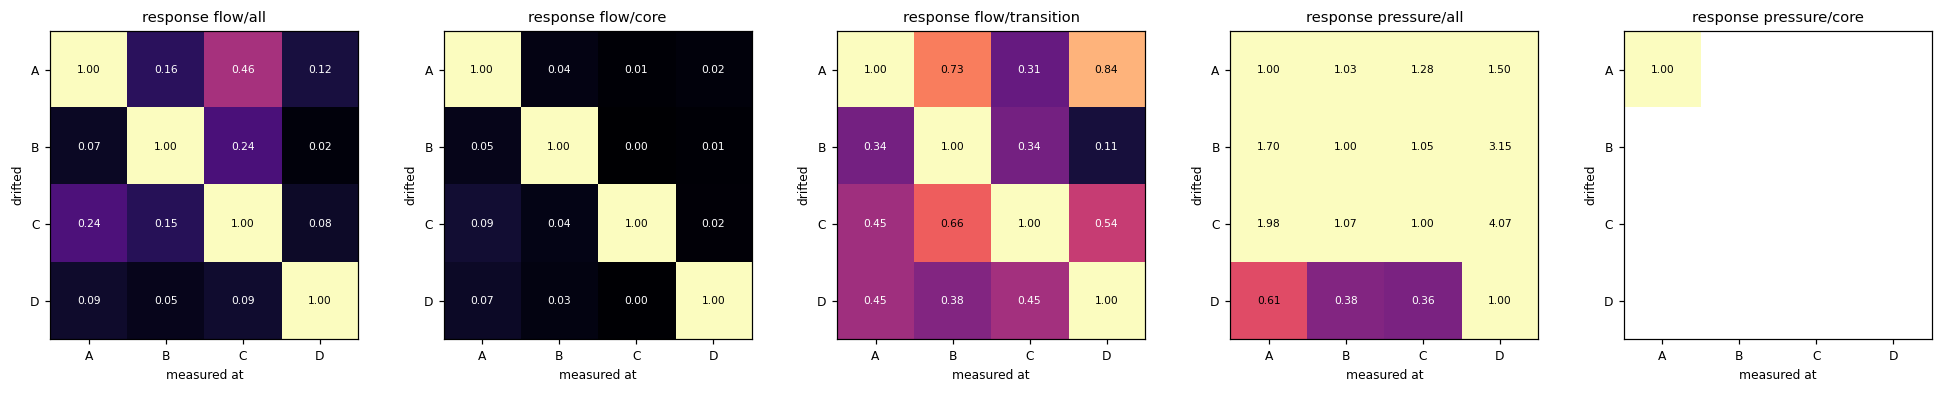

leak (flow): rows drifted, columns measured


,District_A,District_B,District_C,District_D
District_A,1.000,0.099,0.363,0.550
District_B,0.472,1.000,0.420,0.410
District_C,0.559,0.273,1.000,0.489
District_D,0.556,0.298,0.518,1.000


leak (pressure): rows drifted, columns measured


,District_A,District_B,District_C,District_D
District_A,0.648,0.367,0.435,0.293
District_B,0.045,0.147,0.047,0.003
District_C,0.031,0.173,0.091,0.051
District_D,0.050,0.143,0.026,0.359


,network,district,kind,id,role,r_mean,r_std,r_min,count,rank
0,ky72,District_A,flow,q_P-5,internal,0.8760,0.0,0.8760,4,1.0
1,ky72,District_A,flow,q_P-229,internal,0.8323,0.0,0.8323,4,2.0
2,ky72,District_A,flow,q_P-1,internal,0.8130,0.0,0.8130,4,3.0
3,ky72,District_A,flow,q_P-143,internal,0.8091,0.0,0.8091,4,4.0
4,ky72,District_A,flow,q_P-351,internal,0.8019,0.0,0.8019,4,5.0
5,ky72,District_A,pressure,p_J-95,internal,0.1083,0.0,0.1083,4,1.0
6,ky72,District_A,pressure,p_J-151,internal,0.1075,0.0,0.1075,4,2.0
7,ky72,District_A,pressure,p_J-149,internal,0.1060,0.0,0.1060,4,3.0
8,ky72,District_A,pressure,p_J-150,internal,0.1056,0.0,0.1056,4,4.0
9,ky72,District_A,pressure,p_J-94,internal,0.1044,0.0,0.1044,4,5.0


,network,district,kind,id,in_top,cells,share
0,ky72,District_A,flow,q_P-1,4,4,1.0
1,ky72,District_A,flow,q_P-143,4,4,1.0
2,ky72,District_A,flow,q_P-229,4,4,1.0
3,ky72,District_A,flow,q_P-351,4,4,1.0
4,ky72,District_A,flow,q_P-5,4,4,1.0
5,ky72,District_A,pressure,p_J-149,4,4,1.0
6,ky72,District_A,pressure,p_J-150,4,4,1.0
7,ky72,District_A,pressure,p_J-151,4,4,1.0
8,ky72,District_A,pressure,p_J-94,4,4,1.0
9,ky72,District_A,pressure,p_J-95,4,4,1.0


In [9]:
keys = sorted(S.response)
fig, axes = plt.subplots(1, len(keys), figsize=(3.6 * len(keys), 3.4), squeeze=False)
for ax, (kind, use) in zip(axes[0], keys):
    F.matrix(ax, S.response[(kind, use)], title=f"response {kind}/{use}",
             xlabel="measured at", ylabel="drifted")
plt.tight_layout(); plt.show()
for kind, A in S.leak.items():
    print(f"leak ({kind}): rows drifted, columns measured")
    display(A.round(3))
display(S.carriers.head(20))
display(S.carrier_stability.head(20))

## 4. Verification — contiguity, tiers on the map, channel diversity

A mixture is only informative if it **varies between gauges**. `mean_pairwise_tv` measures that
across gauges: a `degenerate` channel reports one blend everywhere (KY7 pressure: the
tank-and-pump state has one degree of freedom). Degenerate channels are **kept** in the
placement and flagged (`channel_verdict`); whether they feed the model is
`fl.preprocessing.channels`, a run-level choice.

,district,kind,n_core,components,largest_share
0,District_A,flow,271,1,1.000000
1,District_B,flow,90,2,0.890000
2,District_C,flow,35,10,0.270833
3,District_D,flow,40,1,1.000000
4,District_A,pressure,10,4,0.500000
5,District_B,pressure,0,0,NaN
6,District_C,pressure,0,0,NaN
7,District_D,pressure,0,0,NaN


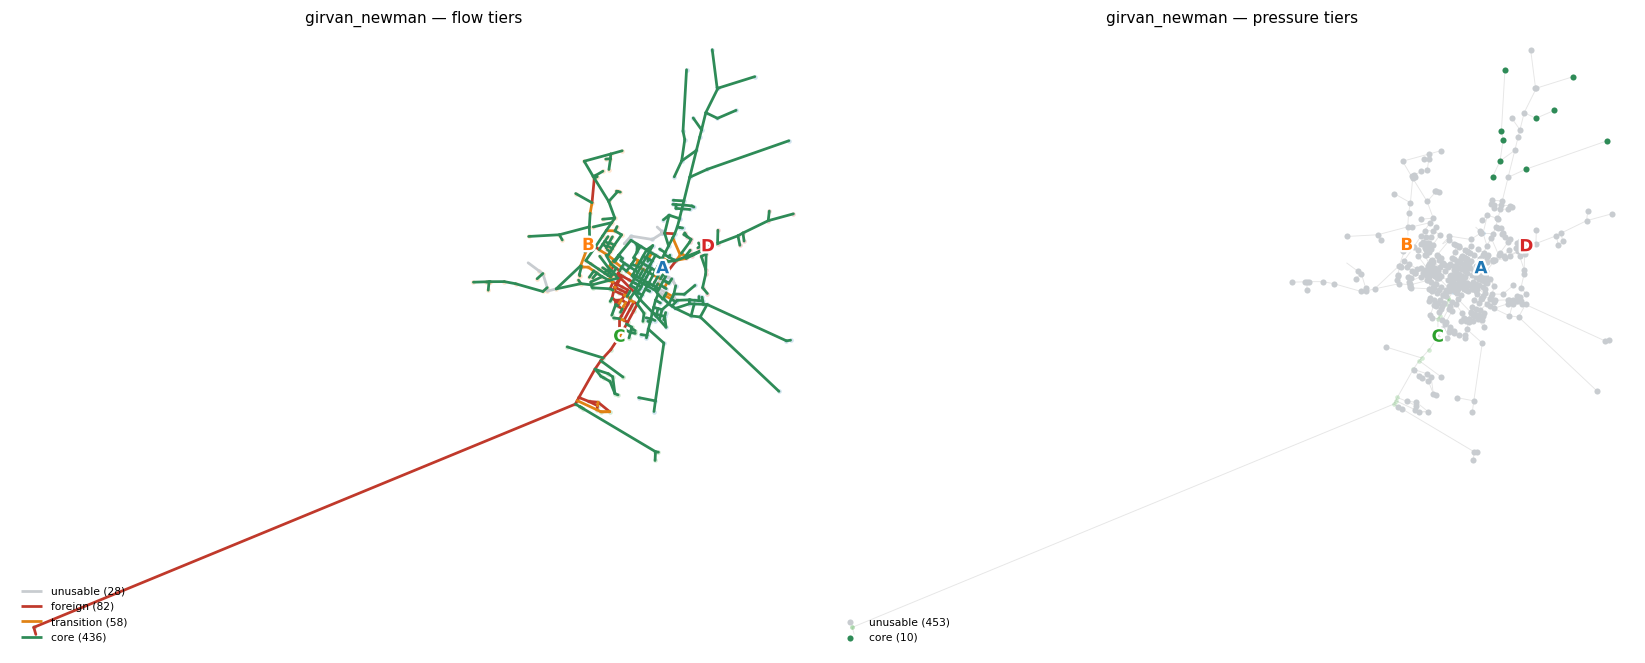

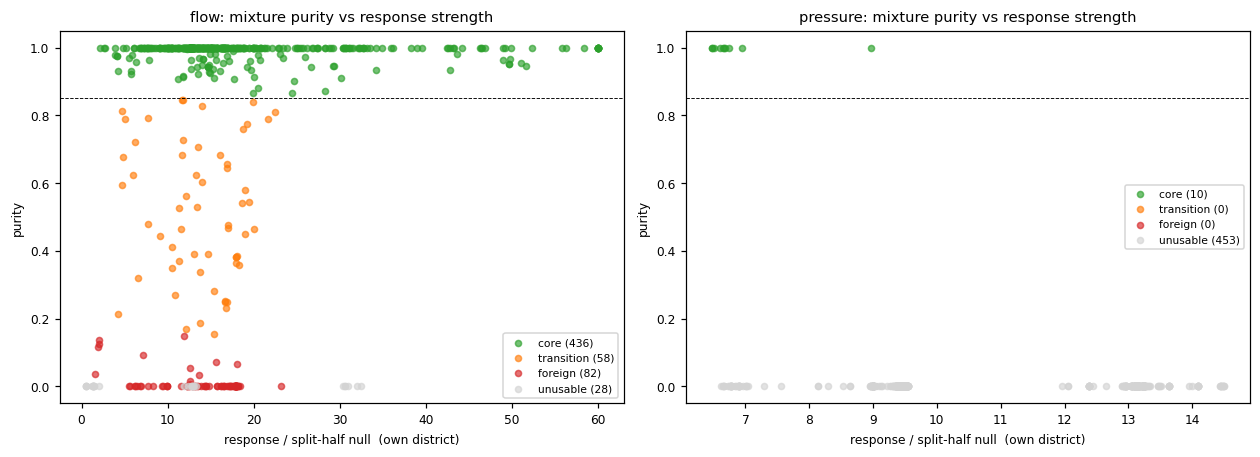

[09/16/26 16:30:33] INFO     Loading data from placement_channels (CSVDataset)...              ]8;id=730301;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=31911;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

,kind,n_live,distinct_rows,distinct_share,mean_pairwise_tv,eff_rank,verdict,stack,stack_hash
0,flow,576,134,0.2326,0.5704,2.724,ok,selection,9daaa69d72b3
1,pressure,10,1,0.1000,0.0000,0.000,degenerate,selection,9daaa69d72b3


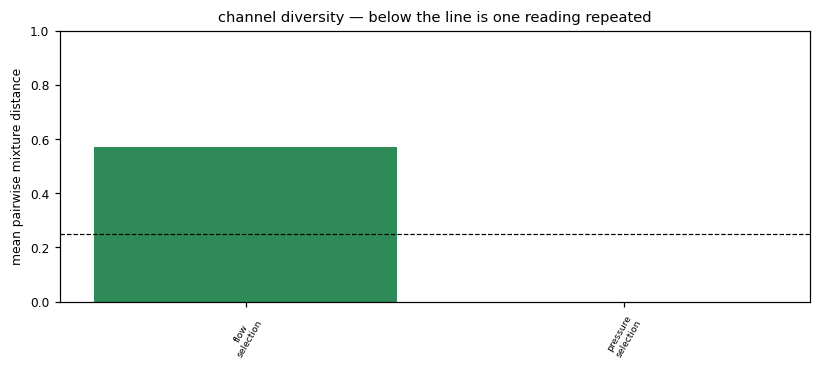

In [10]:
display(S.connectivity)
TAB = cl.classification(S)
fig, ax = plt.subplots(1, 2, figsize=(15, 6.4))
F.tier_network(ax[0], TOPO, TAB, S.districts, "flow", title=f"{S.method} — flow tiers")
F.tier_network(ax[1], TOPO, TAB, S.districts, "pressure", title=f"{S.method} — pressure tiers")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for a, k in zip(ax, ("flow", "pressure")):
    mp.plot_purity({"mixture": S.mixture, "districts": S.names}, k, ax=a)
plt.tight_layout(); plt.show()

CH = catalog.load("placement_channels")
display(CH)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
F.channel_bars(ax, CH.rename(columns={"stack": "config_id"}), min_tv=cl.CHANNEL_MIN_TV)
plt.tight_layout(); plt.show()

## 5. Interactive views

**Stack browser** — the response/leak matrix beside a metric drawn on the network, for the
selection and label stacks side by side. **Mixture browser** — one stack: tiers on the map, the
per-district simplex, dependence and response. **Lab browser** — one probe world: weekly
shapes, the selection map, and the shape-distance clustering.

In [11]:
_ = B.sweep_browser({f"selection:{S.stack_hash}": S,
                     **({} if L is S else {f"label:{L.stack_hash}": L})}, TOPO)

In [12]:
_ = B.mixture_browser(S, TOPO)

In [13]:
D0 = sorted(S.probes)[0]
P0 = S.probes[D0]
SC0 = S.scores[S.scores["drift_district"] == D0]
_ = B.lab_browser(P0, SC0)

## 6. The placement

One row per slot, identical slot names in every district. `filled_as` says how each slot was
filled — `pure` / `mixed` by the book, then the ladder: `pure_redundant`, `mixed_redundant`,
`pure_fill`, `best_available`, `unresponsive`. `sel_*` columns are what the selection stack
saw; the unprefixed mixture columns are the label stack's.

,district,kind,slot,filled_as,sensor,role,sel_tier,tier,purity,second,w_second,w_District_A,w_District_B,w_District_C,w_District_D,channel_verdict
0,District_A,flow,q_pure_0,pure,q_P-552,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,ok
1,District_A,flow,q_pure_1,pure,q_P-63,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,ok
2,District_A,flow,q_pure_2,pure,q_P-204,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,ok
3,District_A,flow,q_mixed_0,mixed,q_P-260,internal,transition,transition,0.543,District_B,0.381,0.543,0.381,0.042,0.034,ok
4,District_A,flow,q_mixed_1,mixed,q_P-291,internal,transition,transition,0.390,District_D,0.482,0.390,0.034,0.094,0.482,ok
5,District_A,pressure,p_pure_0,pure,p_J-95,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,degenerate
6,District_A,pressure,p_pure_1,pure,p_J-94,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,degenerate
7,District_A,pressure,p_pure_2,pure,p_J-151,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,degenerate
8,District_A,pressure,p_mixed_0,pure_fill,p_J-92,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,degenerate
9,District_A,pressure,p_mixed_1,pure_fill,p_J-93,internal,core,core,1.000,NaN,0.000,1.000,0.000,0.000,0.000,degenerate


filled_as            mixed  pure  pure_fill  unresponsive
kind     district                                        
flow     District_A      2     3          0             0
         District_B      2     3          0             0
         District_C      2     3          0             0
         District_D      2     3          0             0
pressure District_A      0     3          2             0
         District_B      0     0          0             5
         District_C      0     0          0             5
         District_D      0     0          0             5

[09/16/26 16:30:46] INFO     Loading data from placement_coverage (CSVDataset)...              ]8;id=268158;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=727433;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

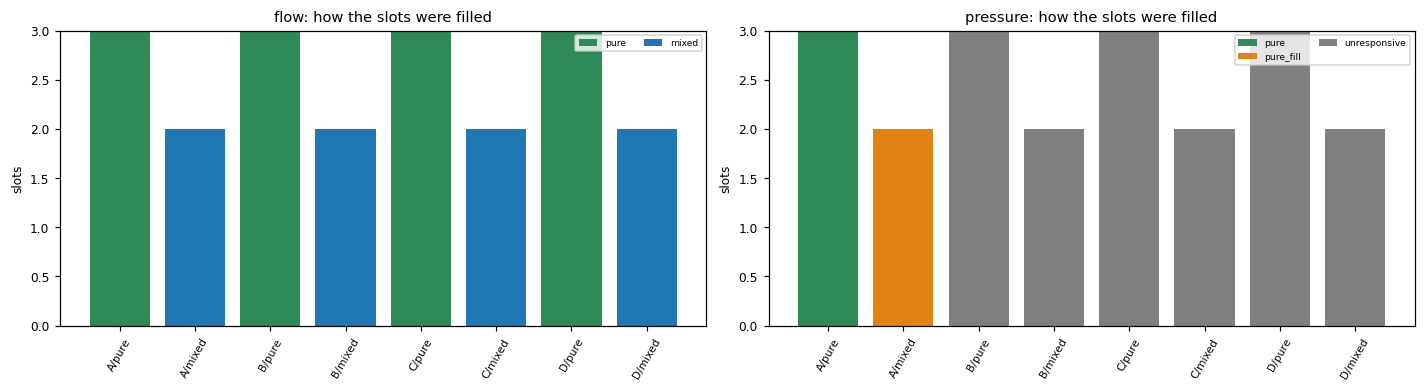

In [14]:
W = [c for c in PLACEMENT.columns if c.startswith("w_") and c != "w_second"]
cols = ["district", "kind", "slot", "filled_as", "sensor", "role", "sel_tier", "tier",
        "purity", "second", "w_second", *W, "channel_verdict"]
display(PLACEMENT[cols].round(3))
display(pd.crosstab([PLACEMENT["kind"], PLACEMENT["district"]], PLACEMENT["filled_as"]))
COV = catalog.load("placement_coverage")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, kind in zip(axes, ("flow", "pressure")):
    F.slot_fill_bars(ax, COV, kind)
plt.tight_layout(); plt.show()

In [15]:
# Where the label stack disagrees with the selection stack (only when they differ)
if L is not S:
    moved = PLACEMENT[(PLACEMENT["sel_tier"] != PLACEMENT["tier"])
                      | ((PLACEMENT["sel_purity"] - PLACEMENT["purity"]).abs() > 0.1)]
    display(moved[["district", "kind", "slot", "sensor", "sel_tier", "tier",
                   "sel_purity", "purity", "sel_w_second", "w_second"]].round(3))
else:
    print("selection and label stacks are the same stack")
display(catalog.load("placement_report_arms"))

selection and label stacks are the same stack


                    INFO     Loading data from placement_report_arms (CSVDataset)...           ]8;id=940683;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=221572;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

,config_id,arm,district,kind,rank,n_eligible,id,element,home,role,tier,purity,w1,w2,top2,second,w_second,snr_home,n_mass,purity_swing,tier_stable,neg_mass,served_own,r_res_own_init,response_mean
0,girvan_newman__9daaa69d72b3,control_low,District_A,flow,1,1,q_P-619,P-619,District_A,internal,foreign,0.0,1.000000,0.000000,1.0,District_B,1.000000,9.885943,1,0.0,True,0.296277,0.521144,-0.007069,-0.006769
1,girvan_newman__9daaa69d72b3,control_low,District_B,flow,1,7,q_P-201,P-201,District_B,internal,foreign,0.0,1.000000,0.000000,1.0,District_A,1.000000,16.168057,1,0.0,True,0.294556,0.204985,0.076148,0.064769
2,girvan_newman__9daaa69d72b3,control_low,District_B,flow,2,7,q_P-325,P-325,District_B,internal,foreign,0.0,1.000000,0.000000,1.0,District_A,1.000000,15.753682,1,0.0,True,0.274038,0.204985,0.074363,0.116316
3,girvan_newman__9daaa69d72b3,control_low,District_B,flow,3,7,q_P-48,P-48,District_B,internal,foreign,0.0,1.000000,0.000000,1.0,District_A,1.000000,14.497194,1,0.0,True,0.288140,0.204985,0.077095,0.119950
4,girvan_newman__9daaa69d72b3,control_low,District_B,flow,4,7,q_P-52,P-52,District_B,internal,foreign,0.0,1.000000,0.000000,1.0,District_A,1.000000,14.339896,1,0.0,True,0.419379,0.204985,0.076363,0.081404
5,girvan_newman__9daaa69d72b3,control_low,District_B,flow,5,7,q_P-96,P-96,District_B,internal,foreign,0.0,1.000000,0.000000,1.0,District_A,1.000000,7.670131,1,0.0,True,0.045426,0.204985,0.059658,0.053303
6,girvan_newman__9daaa69d72b3,control_low,District_C,flow,1,71,q_P-539,P-539,District_C,internal,foreign,0.0,1.000000,0.000000,1.0,District_A,1.000000,23.189532,1,0.0,True,0.576200,0.176752,-0.027176,-0.051326
7,girvan_newman__9daaa69d72b3,control_low,District_C,flow,2,71,q_P-247,P-247,District_C,internal,foreign,0.0,0.958939,0.041061,1.0,District_A,0.958939,18.358635,2,0.0,True,0.218814,0.176752,-0.042786,-0.076689
8,girvan_newman__9daaa69d72b3,control_low,District_C,flow,3,71,q_P-365,P-365,District_C,internal,foreign,0.0,0.862124,0.137876,1.0,District_A,0.862124,17.992325,2,0.0,True,0.168355,0.154924,-0.044237,-0.066543
9,girvan_newman__9daaa69d72b3,control_low,District_C,flow,4,71,q_P-407,P-407,District_C,internal,foreign,0.0,0.864754,0.135246,1.0,District_A,0.864754,17.939636,2,0.0,True,0.179752,0.139705,-0.044372,-0.069342


## 7. Do the selected sets make sense?

Against the **demand profile**: a gauge chosen for its mixture should still be recognisably
reading water — a flat trace against a strongly shaped demand week means the slot holds
something the district's behaviour does not reach. Against **location**: a `mixed` gauge
should sit where districts meet, a `pure` one inside its own. Then the chosen set scored on
axes it was **not** chosen on, and against this world's own drift.

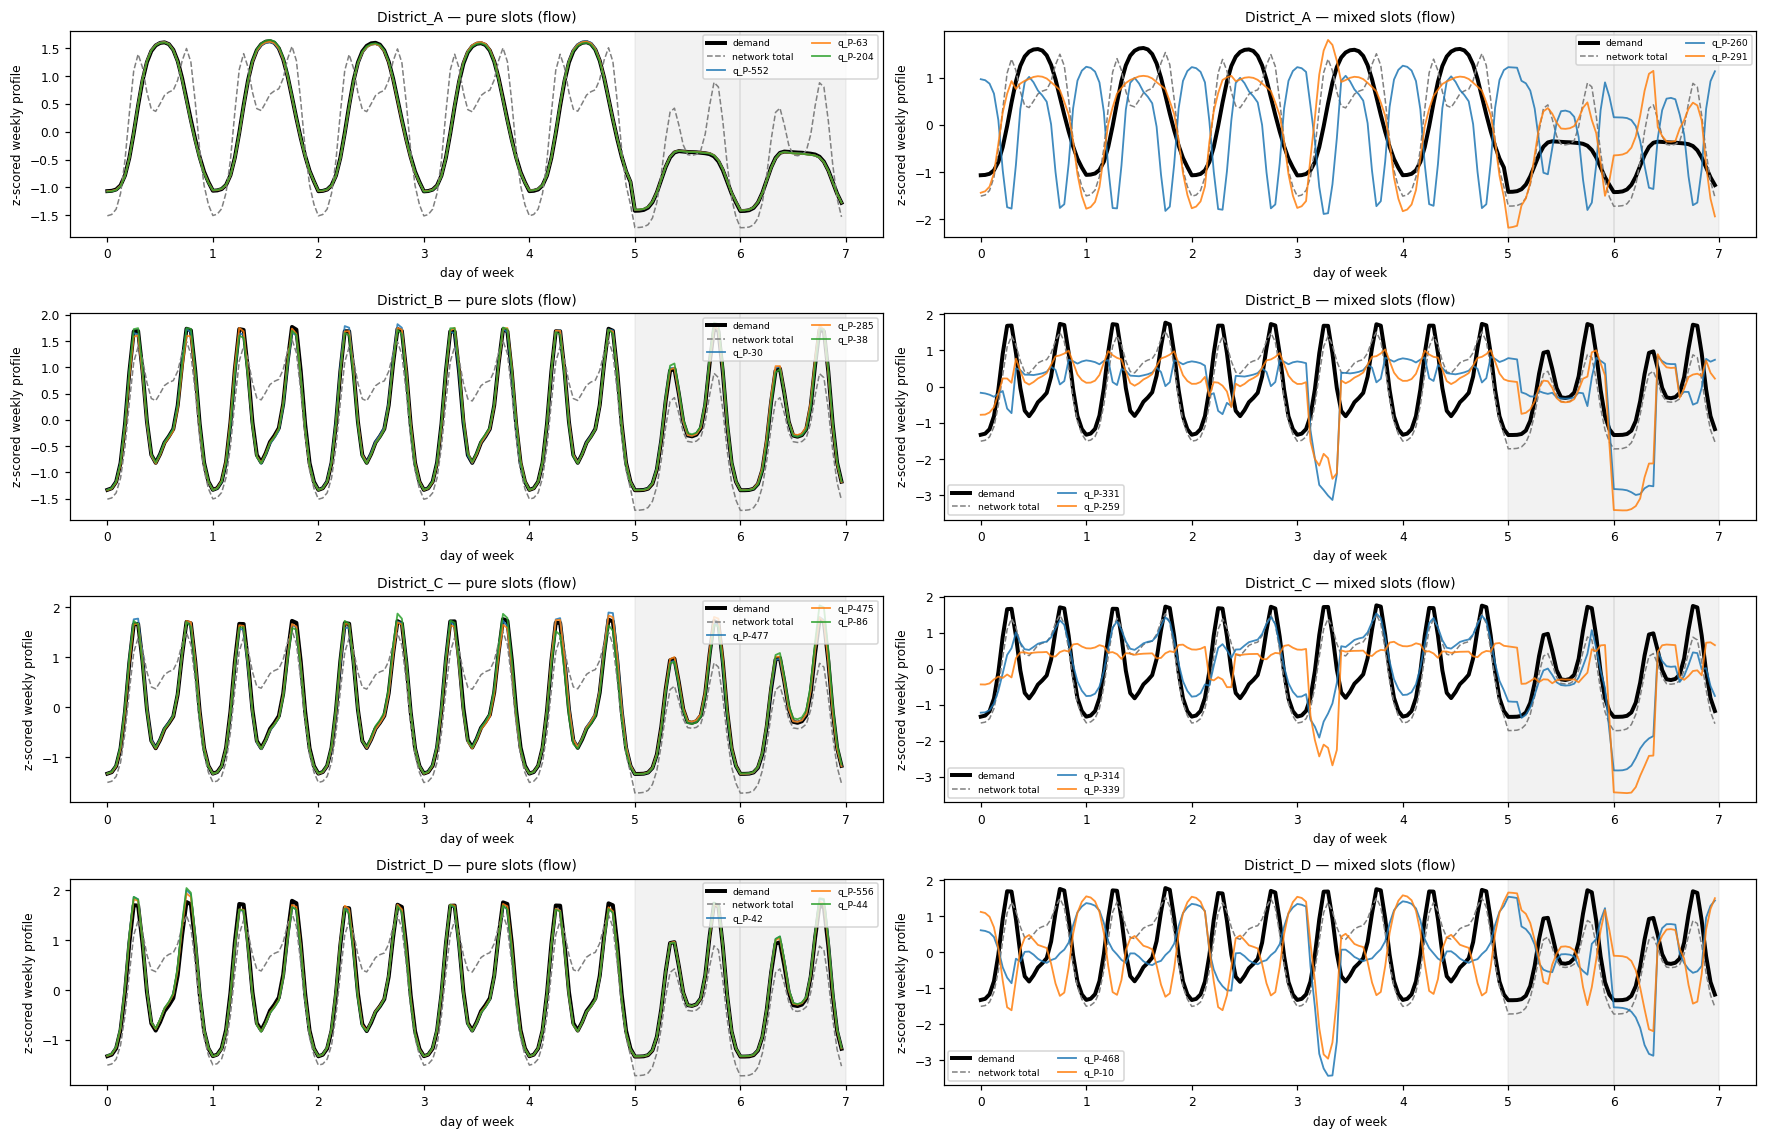

In [23]:
KIND = "flow"
fig, axes = plt.subplots(len(S.names), 2, figsize=(16, 2.6 * len(S.names)), squeeze=False)
for row, d in zip(axes, S.names):
    for ax, cls in zip(row, ("pure", "mixed")):
        ids = list(PLACEMENT[(PLACEMENT["district"] == d) & (PLACEMENT["kind"] == KIND)
                             & (PLACEMENT["slot_class"] == cls)]["sensor"])
        F.selection_vs_demand(ax, P0, ids, d, phase="final")
        ax.set_title(f"{d} — {cls} slots ({KIND})", fontsize=9)
plt.tight_layout(); plt.show()

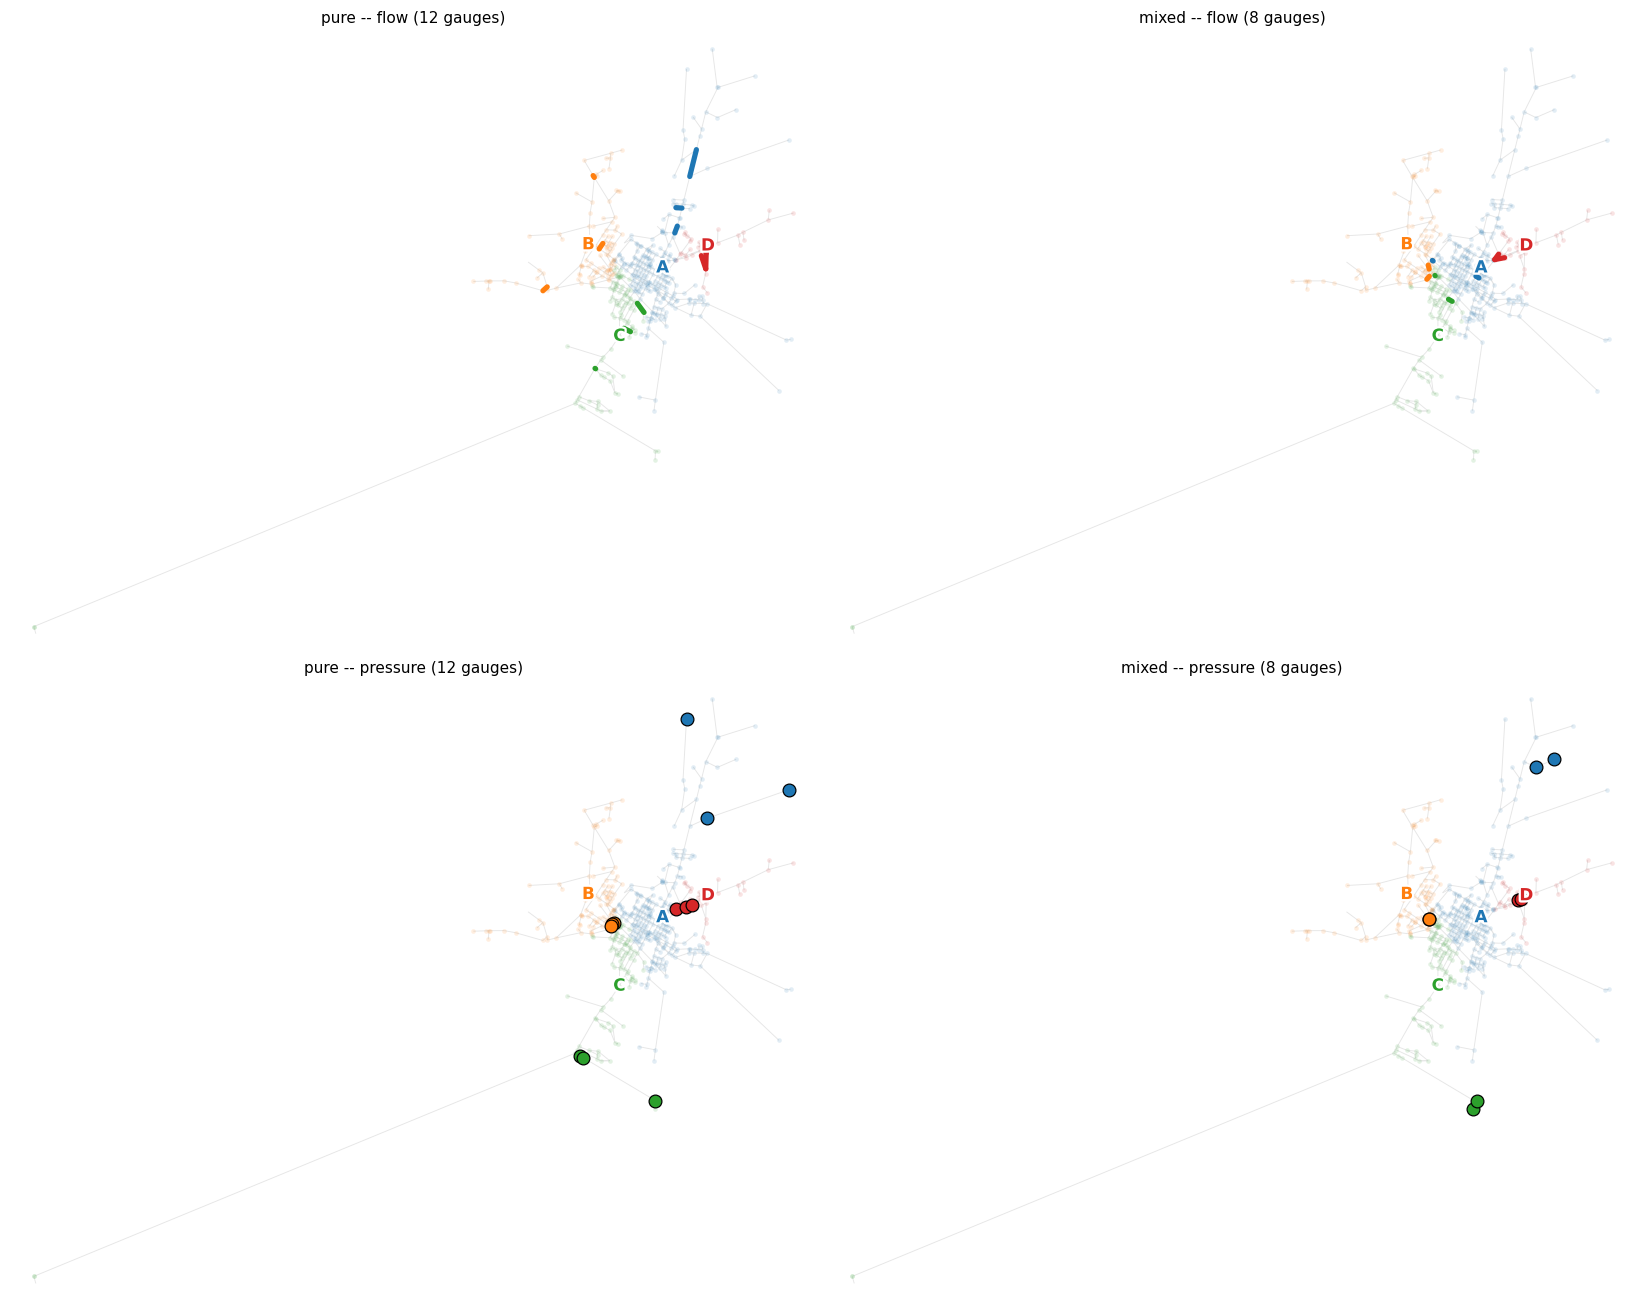

sel_snr_home  sel_served_own  sel_response_mean  sel_r_res_own_init  neg_mass
kind     slot_class filled_as                                                                                  
flow     mixed      mixed               16.870           0.250              0.086               0.020     0.160
         pure       pure                56.139           0.743              0.523               0.313     0.001
pressure mixed      pure_fill            6.669             NaN              0.032               0.098     1.645
                    unresponsive        12.249             NaN             -0.038              -0.052     0.742
         pure       pure                 7.554             NaN              0.189               0.107     1.286
                    unresponsive        12.260             NaN             -0.038              -0.052     0.745

In [17]:
ARMS = PLACEMENT.assign(arm=PLACEMENT["slot_class"])
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for r, kind in enumerate(("flow", "pressure")):
    for c, cls in enumerate(("pure", "mixed")):
        F.selection_network(axes[r][c], TOPO, ARMS, S.districts, cls, kind)
plt.tight_layout(); plt.show()

# scored on axes they were NOT chosen on: `sel_served_own` is the independent
# topological opinion; `sel_r_res_own_init` is not a quality signal on a
# homogeneous initial map (nothing for it to resolve)
cols = [c for c in ("sel_snr_home", "sel_served_own", "sel_response_mean",
                    "sel_r_res_own_init", "neg_mass") if c in PLACEMENT.columns]
display(PLACEMENT.groupby(["kind", "slot_class", "filled_as"])[cols].mean().round(3))

### Against this world's own drift

The one column of the gain matrix the target world itself identifies: for each chosen gauge,
how much of the drift district's change reached it (`observed_g`), next to what the label
stack predicted (`expected_w_drift`). A report, never a gate — a world whose drift has not
settled inside its horizon says `unsettled` here and nothing else.

In [18]:
V = catalog.load("placement_verification")
print(V["status"].iloc[0])
display(V.head(40))

[09/16/26 16:30:48] INFO     Loading data from placement_verification (CSVDataset)...          ]8;id=989835;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=665136;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

unsettled: 1 settled month(s) after the drift completes (month 54), 3 needed; the world horizon is too short to verify


,drift_district,district,kind,slot,slot_class,filled_as,sensor,element,expected_w_drift,status
0,District_A,District_A,flow,q_pure_0,pure,pure,q_P-552,P-552,1.000000,unsettled: 1 settled month(s) after the drift ...
1,District_A,District_A,flow,q_pure_1,pure,pure,q_P-63,P-63,1.000000,unsettled: 1 settled month(s) after the drift ...
2,District_A,District_A,flow,q_pure_2,pure,pure,q_P-204,P-204,1.000000,unsettled: 1 settled month(s) after the drift ...
3,District_A,District_A,flow,q_mixed_0,mixed,mixed,q_P-260,P-260,0.542862,unsettled: 1 settled month(s) after the drift ...
4,District_A,District_A,flow,q_mixed_1,mixed,mixed,q_P-291,P-291,0.389810,unsettled: 1 settled month(s) after the drift ...
5,District_A,District_A,pressure,p_pure_0,pure,pure,p_J-95,J-95,1.000000,unsettled: 1 settled month(s) after the drift ...
6,District_A,District_A,pressure,p_pure_1,pure,pure,p_J-94,J-94,1.000000,unsettled: 1 settled month(s) after the drift ...
7,District_A,District_A,pressure,p_pure_2,pure,pure,p_J-151,J-151,1.000000,unsettled: 1 settled month(s) after the drift ...
8,District_A,District_A,pressure,p_mixed_0,mixed,pure_fill,p_J-92,J-92,1.000000,unsettled: 1 settled month(s) after the drift ...
9,District_A,District_A,pressure,p_mixed_1,mixed,pure_fill,p_J-93,J-93,1.000000,unsettled: 1 settled month(s) after the drift ...


## 8. Read-out

**(a) Does each channel carry a placement?** §4. A `degenerate` channel means every gauge of it
reports the same blend: its slots are filled (`best_available` / `unresponsive` show up in §6)
but they are one reading repeated. Keep it in the world; drop it from the model with
`fl.preprocessing.channels` if the run calls for it.

**(b) Is the dependence real, or is it the threshold?** §3a. If `n_live<=1_%` is high and the
tier counts move across `null_factors`, the mixture is one-hot by construction.

**(c) How much of the placement is by the book?** §6. `mixed_redundant` / `pure_fill` rows are
the ladder working; a district with no `mixed` row has no quantified blend to offer FL at this
partition and operating point — a statement about the cut.

**(d) `R > 1`.** `R` is a ratio to the diagonal, not a fraction: above 1, a district's meters
respond more to someone else's drift than to their own.

**(e) What is NOT claimed.** One operating point per stack: no linearity check, so these
numbers hold at this beta, anchor and coupling. Influence, not causality. The honest sample
size for cross-partition statements is the number of partitions, not the number of gauges.

**(f) Anti-phase mass.** `classification.rebuild_mixture(gains, kind, mode="magnitude")` is a
diagnostic, not a shipped path: the simplex drops negative gains while `dependence()` averages
`|E|`. Prove any gain from it with `channel_diversity` before trusting it.